# PyTorch — L’essentiel du framework

**Objectifs :**
- comprendre les `Tensor` ;
- utiliser `Autograd` ;
- construire un modèle avec `nn.Module` ;
- définir un `Loss` et un `Optimizer` ;
- écrire une boucle d’apprentissage ;
- distinguer `train()` et `eval()` ;
- utiliser `Dataset` / `DataLoader` ;
- entraîner un exemple de régression et un exemple de classification ;
- sauvegarder et recharger un modèle.

## 0. Préparation

Le notebook fonctionne sur CPU. S’il existe un GPU CUDA, PyTorch pourra l’utiliser automatiquement.

In [47]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

PyTorch version: 2.10.0
CUDA disponible: False


## 1. Workflow général

Le cycle de base est :

**Données → Tensors → Modèle → Prédictions → Loss → Backward → Optimizer → Mise à jour**

In [48]:
# Pseudo-code de la logique générale
# y_pred = model(X)
# loss = criterion(y_pred, y)
# optimizer.zero_grad()
# loss.backward()
# optimizer.step()

## 2. Les Tensors

Un `Tensor` est la structure de données fondamentale de PyTorch.

In [49]:
scalar = torch.tensor(3.0)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

print("scalar:", scalar, "shape =", scalar.shape)
print("vector:", vector, "shape =", vector.shape)
print("matrix:", matrix, "shape =", matrix.shape)
print("dtype:", matrix.dtype)
print("ndim:", matrix.ndim)

scalar: tensor(3.) shape = torch.Size([])
vector: tensor([1., 2., 3.]) shape = torch.Size([3])
matrix: tensor([[1., 2.],
        [3., 4.]]) shape = torch.Size([2, 2])
dtype: torch.float32
ndim: 2


### Manipulation de Tensors

In [50]:
x = torch.arange(12)
print("x =", x)

x2 = x.reshape(3, 4)
print("reshape(3,4):", x2)

print("Colonne 1:", x2[:, 1])
print("Ligne 0:", x2[0, :])

A = torch.tensor([[1., 2.], [3., 4.]])
B = torch.tensor([[2., 0.], [1., 2.]])
print("A @ B =", A @ B)

print("mean(A) =", A.mean())
print("sum(A) =", A.sum())

x = tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
reshape(3,4): tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Colonne 1: tensor([1, 5, 9])
Ligne 0: tensor([0, 1, 2, 3])
A @ B = tensor([[ 4.,  4.],
        [10.,  8.]])
mean(A) = tensor(2.5000)
sum(A) = tensor(10.)


## 3. CPU, GPU et `device`

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé:", device)

x = torch.tensor([1.0, 2.0, 3.0]).to(device)
print("x.device =", x.device)

Device utilisé: cpu
x.device = cpu


## 4. Autograd

`Autograd` calcule automatiquement les dérivées à partir du graphe de calcul.

In [52]:
x = torch.tensor(2.0)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y = w * x + b
loss = (y - 10) ** 2

loss.backward()

print("y =", y.item())
print("loss =", loss.item())
print("dLoss/dw =", w.grad.item())
print("dLoss/db =", b.grad.item())

y = 7.0
loss = 9.0
dLoss/dw = -12.0
dLoss/db = -6.0


In [53]:
import torch

x = torch.tensor(2.0)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y = w * x + b
loss = (y - 10) ** 2

dw, db = torch.autograd.grad(loss, (w, b))

print("y =", y.item())
print("loss =", loss.item())
print("dLoss/dw =", dw.item())
print("dLoss/db =", db.item())

y = 7.0
loss = 9.0
dLoss/dw = -12.0
dLoss/db = -6.0


### Vérification analytique

Ici :

\[
y = wx+b
\]

et

\[
L=(y-10)^2
\]

Donc :

\[

rac{\partial L}{\partial w}=2(y-10)x
\]

\[

rac{\partial L}{\partial b}=2(y-10)
\]

In [54]:
y_val = (3.0 * 2.0 + 1.0)
dL_dw = 2 * (y_val - 10) * 2.0
dL_db = 2 * (y_val - 10)
print(dL_dw, dL_db)

-12.0 -6.0


## 5. Un neurone avec `nn.Linear`

Un neurone linéaire calcule essentiellement :

\[
z = \sum_i w_i x_i + b
\]

In [55]:
model = nn.Linear(3, 1)
x = torch.tensor([[1.0, 2.0, 3.0]])
y = model(x)

print("Sortie:", y)
print("Poids:", model.weight)
print("Biais:", model.bias)

Sortie: tensor([[0.1135]], grad_fn=<AddmmBackward0>)
Poids: Parameter containing:
tensor([[ 0.1652, -0.1261,  0.2248]], requires_grad=True)
Biais: Parameter containing:
tensor([-0.4738], requires_grad=True)


In [56]:
import torch
import torch.nn as nn
from torchviz import make_dot

model = nn.Linear(3, 1)
x = torch.tensor([[1.0, 2.0, 3.0]])
y = model(x)

print("Sortie:", y)
print("Poids:", model.weight)
print("Biais:", model.bias)

dot = make_dot(y, params=dict(model.named_parameters()))
dot.render("graphe_operations", format="png", cleanup=True)

Sortie: tensor([[-0.5975]], grad_fn=<AddmmBackward0>)
Poids: Parameter containing:
tensor([[ 0.4286, -0.4238, -0.0997]], requires_grad=True)
Biais: Parameter containing:
tensor([0.1206], requires_grad=True)


'graphe_operations.png'

## 6. Construire un réseau avec `nn.Module`

In [57]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3)
        )

    def forward(self, x):
        return self.net(x)

model = MLP()
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)


In [58]:
model = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3)
        )
print(model)

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=3, bias=True)
)


## 7. Fonctions d’activation

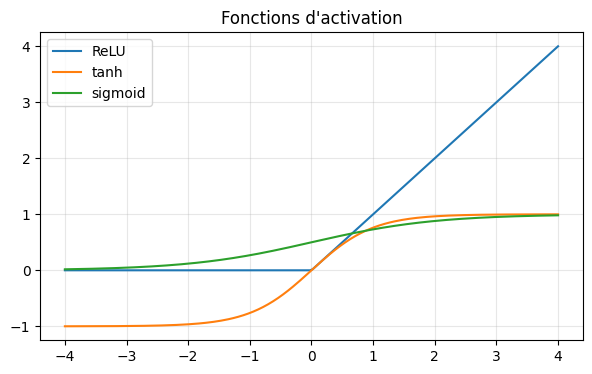

In [59]:
x = torch.linspace(-4, 4, 200)
relu = torch.relu(x)
tanh = torch.tanh(x)
sigmoid = torch.sigmoid(x)

plt.figure(figsize=(7,4))
plt.plot(x.numpy(), relu.numpy(), label='ReLU')
plt.plot(x.numpy(), tanh.numpy(), label='tanh')
plt.plot(x.numpy(), sigmoid.numpy(), label='sigmoid')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Fonctions d'activation")
plt.show()

## 8. Forward propagation

L’appel `model(X)` déclenche automatiquement `model.forward(X)`.

In [60]:
X = torch.randn(5, 4)
# L’appel model(X) déclenche automatiquement model.forward(X)
predicted = model(X)
print("Shape entrée :", X.shape)
print("Shape sortie :", predicted.shape)

Shape entrée : torch.Size([5, 4])
Shape sortie : torch.Size([5, 3])


## 9. Fonctions de coût

Cas principaux :
- régression : `nn.MSELoss()` ;
- classification multi-classe : `nn.CrossEntropyLoss()` ;
- classification binaire : `nn.BCEWithLogitsLoss()`.

In [61]:
# Régression
criterion_reg = nn.MSELoss()
y_pred = torch.tensor([[2.0], [4.0]])
y_true = torch.tensor([[3.0], [5.0]])
print("MSE =", criterion_reg(y_pred, y_true).item())

# Classification multi-classe
criterion_cls = nn.CrossEntropyLoss()
pred = torch.tensor([[2.0, 1.0, 0.5], [0.2, 0.1, 2.0]])
y = torch.tensor([0, 2])
print("CrossEntropy =", criterion_cls(pred, y).item())

MSE = 1.0
CrossEntropy = 0.36905235052108765


## 10. Optimizers

L’optimiseur utilise les gradients pour mettre à jour les paramètres.

In [62]:
simple_model = nn.Linear(1, 1)
optimizer = torch.optim.Adam(simple_model.parameters(), lr=1e-2)
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


## 11. La boucle d’apprentissage

C’est le cœur de PyTorch.

In [63]:
X = torch.randn(8, 1)
y = 2 * X + 1
simple_model = nn.Linear(1, 1)
optimizer = torch.optim.Adam(simple_model.parameters(), lr=1e-2)
criterion = nn.MSELoss()
epochs = 500
# Exemple générique
for epoch in range(epochs):
    simple_model.train()
    y_pred = simple_model(X)
    loss = criterion(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 ==0 : 
        print(f"epoch={epoch} loss={loss.item():.4f}")

epoch=0 loss=14.4736
epoch=100 loss=6.4417
epoch=200 loss=2.4459
epoch=300 loss=0.7627
epoch=400 loss=0.1909


## 12. `train()` vs `eval()`

`model.train()` et `model.eval()` influencent notamment le comportement de `Dropout` et `BatchNorm`.

`eval()` ne désactive pas le calcul des gradients. Pour l’inférence, on utilise généralement `torch.inference_mode()`.

In [64]:
class DropoutDemo(nn.Module):
    def __init__(self):
        super().__init__()
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        return self.dropout(x)

m = DropoutDemo()
x = torch.ones(10)

m.train()
print("train() :", m(x))

m.eval()
with torch.inference_mode():
    print("eval()  :", m(x))

train() : tensor([2., 2., 0., 0., 2., 0., 2., 2., 2., 0.])
eval()  : tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


## 13. Dataset et DataLoader

In [65]:
X = torch.randn(100, 3)
y = torch.randn(100, 1)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

for X_batch, y_batch in loader:
    print("Batch X:", X_batch.shape, "Batch y:", y_batch.shape)
    break

Batch X: torch.Size([16, 3]) Batch y: torch.Size([16, 1])


# Partie pratique 1 — Régression linéaire

Nous générons des données proches de :

\[
y = 3x + 2 + bruit
\]

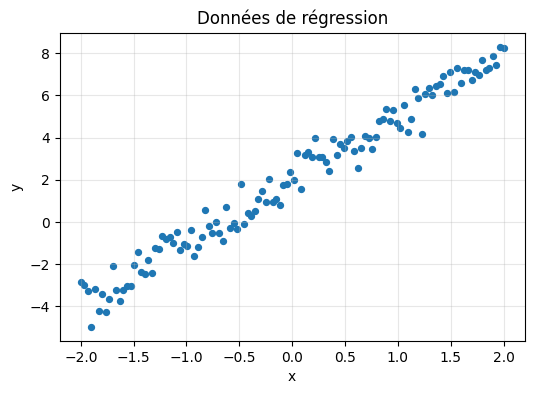

In [66]:
torch.manual_seed(42)

X = torch.linspace(-2, 2, 120).unsqueeze(1)
noise = 0.6 * torch.randn_like(X)
y = 3 * X + 2 + noise

plt.figure(figsize=(6,4))
plt.scatter(X.numpy(), y.numpy(), s=18)
plt.title("Données de régression")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

## 14. Modèle, loss et optimizer

In [67]:
model_reg = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_reg.parameters(), lr=0.05)

## 15. Entraînement de la régression

In [68]:
losses = []

for epoch in range(300):
    model_reg.train()

    y_pred = model_reg(X)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

print("Dernier loss:", losses[-1])
print("w appris:", model_reg.weight.item())
print("b appris:", model_reg.bias.item())

Dernier loss: 0.3438418209552765
w appris: 2.9894580841064453
b appris: 2.030014753341675


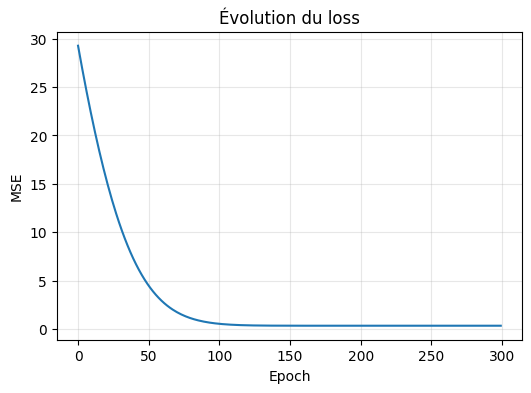

In [69]:
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Évolution du loss")
plt.grid(True, alpha=0.3)
plt.show()

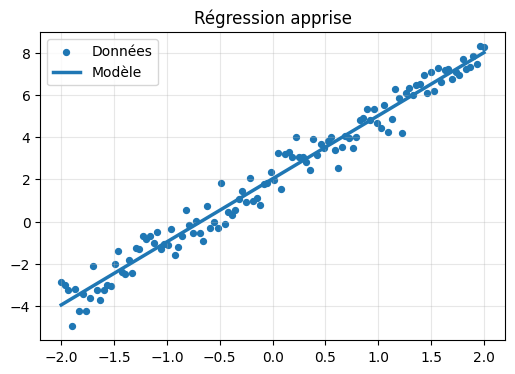

In [70]:
model_reg.eval()
with torch.inference_mode():
    y_hat = model_reg(X)

plt.figure(figsize=(6,4))
plt.scatter(X.numpy(), y.numpy(), s=18, label="Données")
plt.plot(X.numpy(), y_hat.numpy(), linewidth=2.5, label="Modèle")
plt.legend()
plt.title("Régression apprise")
plt.grid(True, alpha=0.3)
plt.show()

In [71]:
from torcheval.metrics import R2Score
metric = R2Score()
metric.update(y_hat,y)
r2=metric.compute()
print(f"R2 Score = {r2:.3f}")

R2 Score = 0.972


# Partie pratique 2 — Classification

Créons deux classes de points en 2D.

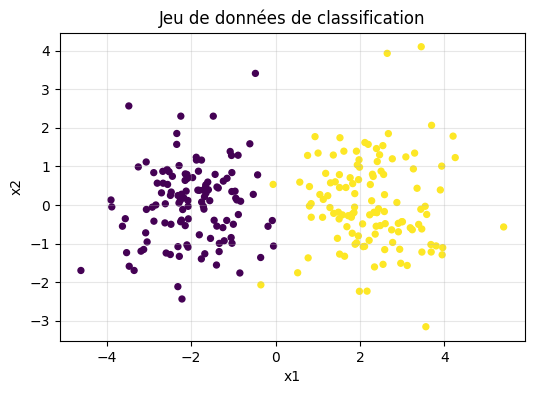

In [72]:
torch.manual_seed(0)

n = 120
class0 = torch.randn(n, 2) + torch.tensor([-2.0, 0.0])
class1 = torch.randn(n, 2) + torch.tensor([ 2.0, 0.0])

X_cls = torch.cat([class0, class1], dim=0)
y_cls = torch.cat([
    torch.zeros(n, dtype=torch.long),
    torch.ones(n, dtype=torch.long)
])

plt.figure(figsize=(6,4))
plt.scatter(X_cls[:,0], X_cls[:,1], c=y_cls, s=18)
plt.title("Jeu de données de classification")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.3)
plt.show()

## 16. Modèle de classification

In [73]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        return self.net(x)

model_cls = Classifier()
criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = torch.optim.Adam(model_cls.parameters(), lr=0.01)

## 17. Entraînement de la classification

In [74]:
losses_cls = []

for epoch in range(250):
    model_cls.train()

    logits = model_cls(X_cls)
    loss = criterion_cls(logits, y_cls)

    optimizer_cls.zero_grad()
    loss.backward()
    optimizer_cls.step()

    losses_cls.append(loss.item())

print("Dernier loss:", losses_cls[-1])

Dernier loss: 0.0006943692569620907


In [75]:
model_cls.eval()
with torch.inference_mode():
    logits = model_cls(X_cls)
    pred = logits.argmax(dim=1)
    accuracy = (pred == y_cls).float().mean()

print(f"Accuracy = {accuracy.item()*100:.2f}%")

Accuracy = 100.00%


Accuracy = 1.0000, recall= 1.0000, precision=1.0000, f1score=1.0000
tensor([[120,   0],
        [  0, 120]])


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

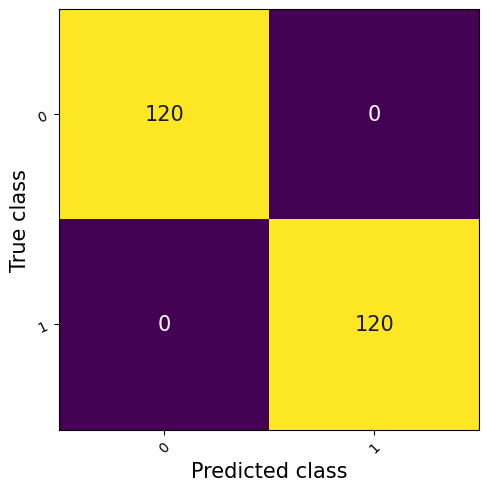

In [82]:
from torcheval.metrics import BinaryAccuracy, BinaryRecall, BinaryPrecision, BinaryPrecision, BinaryF1Score
from torchmetrics.classification import MulticlassConfusionMatrix, BinaryConfusionMatrix
accuracy_metric = BinaryAccuracy()
accuracy_metric.update(y_cls,pred)
accuracy_value = accuracy_metric.compute()

recall_metric = BinaryRecall()
recall_metric.update(y_cls, pred)
recall_value = recall_metric.compute()

precision_metric = BinaryPrecision()
precision_metric.update(y_cls,pred)
precision_value = precision_metric.compute()

f1_score_metric = BinaryF1Score()
f1_score_metric.update(y_cls, pred)
f1_score_value = f1_score_metric.compute()
print(f"Accuracy = {accuracy_value:.4f}, recall= {recall_value:.4f}, precision={precision_value:.4f}, f1score={f1_score_value:.4f}")

metric = BinaryConfusionMatrix()
confusion_matrix = metric(pred, y_cls)
print(confusion_matrix)
metric.plot()

## Visualisation de la frontière de décision

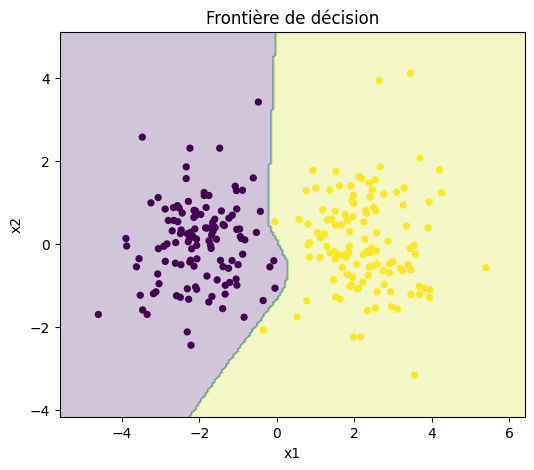

In [77]:
x1_min, x1_max = X_cls[:,0].min()-1, X_cls[:,0].max()+1
x2_min, x2_max = X_cls[:,1].min()-1, X_cls[:,1].max()+1

xx1, xx2 = torch.meshgrid(
    torch.linspace(x1_min, x1_max, 200),
    torch.linspace(x2_min, x2_max, 200),
    indexing='ij'
)

grid = torch.stack([xx1.reshape(-1), xx2.reshape(-1)], dim=1)

model_cls.eval()
with torch.inference_mode():
    zz = model_cls(grid).argmax(dim=1).reshape(xx1.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx1.numpy(), xx2.numpy(), zz.numpy(), alpha=0.25)
plt.scatter(X_cls[:,0], X_cls[:,1], c=y_cls, s=18)
plt.title("Frontière de décision")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 18. Sauvegarder et recharger un modèle

In [78]:
path = "classifier_state_dict.pt"
torch.save(model_cls.state_dict(), path)
print("Modèle sauvegardé dans", path)

new_model = Classifier()
new_model.load_state_dict(torch.load(path, weights_only=True))
new_model.eval()

with torch.inference_mode():
    pred_new = new_model(X_cls).argmax(dim=1)

print("Prédictions identiques:", torch.equal(pred, pred_new))

Modèle sauvegardé dans classifier_state_dict.pt
Prédictions identiques: True


# Synthèse

Les briques essentielles de PyTorch sont maintenant en place :

1. `Tensor`
2. `nn.Module`
3. `forward()`
4. fonction de coût
5. `optimizer.zero_grad()`
6. `loss.backward()`
7. `optimizer.step()`
8. `train()` / `eval()`
9. `Dataset` / `DataLoader`
10. sauvegarde avec `state_dict()`

Cette mécanique reste pratiquement la même pour des modèles plus avancés : CNN, Transformers, modèles génératifs ou PINNs.

# Exercices

### Exercice 1 : Régression

Prédire le salaire selon l’ancienneté et le niveau d’expertise

Objectif:

Construire un modèle de régression linéaire multiple pour prédire le salaire mensuel à partir de deux variables :
- Ancienneté : nombre d’années d’expérience.
- Niveau d’expertise : note de 1 à 5.
Le modèle doit apprendre la relation :

Salaire = w_1 * Ancienneté + w_2 * Expertise + b 

Les salaires sont exprimés en dirhams (DH). Les données sont fictives et servent uniquement à l’apprentissage.

1. *Générer les données*

Pour cet exercice, on suppose que les salaires suivent approximativement la règle : Salaire = 4000 + 600 * Ancienneté + 1500 * Expertise} + Bruit
Le bruit représente les variations individuelles non expliquées par les deux variables.

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Nombre de salariés
n = 300

# Ancienneté : de 0 à 20 ans
anciennete = torch.randint(0, 21, (n, 1)).float()

# Expertise : de 1 à 5
expertise = torch.randint(1, 6, (n, 1)).float()

# Variations aléatoires des salaires
bruit = torch.randn(n, 1) * 500

# Salaire mensuel en DH
salaires = (
    4000
    + 600 * anciennete
    + 1500 * expertise
    + bruit
)

# Matrice des entrées : dimensions (300, 2)
X = torch.cat([anciennete, expertise], dim=1)

# Sortie : dimensions (300, 1)
y = salaires

for i in range(5):
    print(
        f"Ancienneté : {X[i, 0].item():.0f} ans | "
        f"Expertise : {X[i, 1].item():.0f}/5 | "
        f"Salaire : {y[i, 0].item():.2f} DH"
    )

Ancienneté : 15 ans | Expertise : 2/5 | Salaire : 16262.90 DH
Ancienneté : 2 ans | Expertise : 3/5 | Salaire : 10541.39 DH
Ancienneté : 4 ans | Expertise : 3/5 | Salaire : 10948.37 DH
Ancienneté : 19 ans | Expertise : 3/5 | Salaire : 20028.54 DH
Ancienneté : 18 ans | Expertise : 2/5 | Salaire : 18036.38 DH


**Travail demandé**

- Affichez les dimensions de X et de y.
- Calculez le salaire moyen.
- Tracez un nuage de points représentant le salaire selon l’ancienneté, avec une couleur différente selon l’expertise.


2. *Séparer et préparer les données*
Utilisez 80 % des données pour l’entraînement et 20 % pour le test.

Pour faciliter l’apprentissage :

standardisez les entrées à partir des statistiques du jeu d’entraînement ;
exprimez les salaires en milliers de DH.

In [3]:
indices = torch.randperm(n)
limite = int(0.8 * n)

train_indices = indices[:limite]
test_indices = indices[limite:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices] / 1000
y_test = y[test_indices] / 1000

# Statistiques calculées uniquement sur le jeu d'entraînement
moyenne = X_train.mean(dim=0, keepdim=True)
ecart_type = X_train.std(dim=0, keepdim=True)

X_train_norm = (X_train - moyenne) / ecart_type
X_test_norm = (X_test - moyenne) / ecart_type

3. *Construire et entraîner le modèle*

In [ ]:
# Deux variables d'entrée et une sortie
model = nn.Linear(..., ...)

# Erreur quadratique moyenne
criterion = nn.MSELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.05
)

historique = []

model.train()

for epoch in range(500):
    # 1. Réinitialiser les gradients
    optimizer.zero_grad()

    # 2. Prédire les salaires
    predictions = ...

    # 3. Calculer la perte
    loss = ...

    # 4. Calculer les gradients
    ...

    # 5. Mettre à jour les paramètres
    ...

    historique.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(
            f"Époque {epoch + 1} | "
            f"Perte : {loss.item():.4f}"
        )

Travail demandé :

- Complétez le modèle et la boucle d’entraînement.
- Tracez l’évolution de la perte :


In [ ]:
plt.plot(historique)
plt.xlabel("Époque")
plt.ylabel("MSE — salaires en milliers de DH")
plt.title("Évolution de la perte d'entraînement")
plt.grid()
plt.show()

4. Évaluer les prédictions

In [ ]:
model.eval()

with torch.no_grad():
    predictions_test = model(X_test_norm)

    # Conversion en DH
    predictions_dh = predictions_test * 1000
    salaires_reels_dh = y_test * 1000

    # À compléter
    mae = ...

print(f"Erreur absolue moyenne : {mae.item():.2f} DH")

Interprétation : une MAE de 400 DH signifie que les prédictions s’écartent, en moyenne, de 400 DH des salaires réels.

5. Prédire le salaire d’un nouveau salarié

Prédisez le salaire d’une personne ayant :

- 7 ans d’ancienneté ;
- un niveau d’expertise de 4/5.

In [ ]:
nouveau_salarie = torch.tensor([[7.0, 4.0]])

# Appliquer la même normalisation qu'à l'entraînement
nouveau_salarie_norm = ...

with torch.no_grad():
    salaire_predit = ...

print(f"Salaire estimé : {salaire_predit.item():.2f} DH")

Vérification : d’après la règle de génération, le salaire sans bruit est :

4000 + 600 * 7 + 1500 * 4 = 14200 DH

Votre prédiction devrait être proche de cette valeur.

Questions complémentaires :

- À expertise constante, quel est l’effet d’une année d’ancienneté supplémentaire ?
- Pourquoi la perte ne devient-elle pas exactement nulle ?
- Le modèle est-il fiable pour une ancienneté de 40 ans, absente des données d’entraînement ?
- Quel effet aurait une augmentation du bruit sur la précision ?
- Retrouvez les coefficients en unités d’origine à partir des paramètres du modèle entraîné. Ils devraient être proches de 600, 1500 et 4000.

Remarque : traiter l’expertise comme une note numérique suppose que chaque passage d’un niveau au suivant a le même effet sur le salaire. Cette hypothèse simplifie l’exercice, mais doit être vérifiée avec des données réelles.

**1. Préparation des données**

In [6]:
import torch
from torch import nn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)

# Charger les données
iris = load_iris()
X, y = iris.data, iris.target

# Séparer les données : 80 % entraînement, 20 % test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Ajuster la normalisation uniquement sur l'entraînement
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convertir en tenseurs
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print("Dimensions :", X_train.shape, y_train.shape)

Dimensions : torch.Size([120, 4]) torch.Size([120])


**Questions :**

- Que représentent les quatre colonnes de X_train ?
- Pourquoi utilise-t-on torch.long pour les étiquettes ?
- Pourquoi ne faut-il pas ajuster le StandardScaler sur les données de test ?

**2. Construire le réseau**

In [ ]:
model = nn.Sequential(
    nn.Linear(..., ...),
    nn.ReLU(),
    nn.Linear(..., ...)
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

Attention : n’ajoutez pas de Softmax à la sortie. CrossEntropyLoss attend directement les scores bruts, appelés logits.

**3. Entraîner le modèle**

Complétez la boucle d’entraînement. Pour cet exercice, chaque itération utilise toutes les données d’entraînement.

In [ ]:
epochs = 200
losses = []

model.train()

for epoch in range(epochs):
    # TODO : remettre les gradients à zéro
    ...

    # TODO : calculer les scores prédits
    logits = ...

    # TODO : calculer la perte
    loss = ...

    # TODO : calculer les gradients
    ...

    # TODO : mettre à jour les paramètres
    ...

    losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Époque {epoch + 1:3d} | Perte : {loss.item():.4f}")

**4. Évaluer le classifieur**

Complétez le calcul des prédictions et de l’accuracy, c’est-à-dire la proportion de fleurs correctement classées.

In [ ]:
model.eval()

with torch.no_grad():
    logits = model(X_test)

    # TODO : sélectionner la classe au score maximal pour chaque fleur
    predictions = ...

    # TODO : calculer la proportion de prédictions correctes
    accuracy = ...

print(f"Accuracy sur le test : {accuracy.item():.1%}")

**5- Autres question :**

- Tracez la courbe de perte.
- Affichez une matrice de confusion.
- Comparez ce réseau à un modèle sans couche cachée : nn.Linear(4, 3).
- Prédisez l’espèce d’une nouvelle fleur de mesures [5.1, 3.5, 1.4, 0.2], après l’avoir normalisée avec le même scaler.

###  Exercice 3  — Classification des fleurs Iris 🌸

Objectif : entraîner un réseau de neurones pour prédire l’espèce d’une fleur à partir de quatre mesures :

- longueur et largeur des sépales ;
- longueur et largeur des pétales.

Le jeu de données Iris contient 150 fleurs réparties en trois classes : setosa, versicolor et virginica.


Bibliothèques : torch, scikit-learn.

### Exercice 2 : Classifier les chiffres MNIST
Objectif : utiliser des mini-lots et évaluer un modèle sur des données de test.

Chargement des données

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True
)

test_loader = DataLoader(
    test_dataset, batch_size=256, shuffle=False
)

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#### Travail demandé : 
- Entraînez le modèle pendant 5 époques.
- Utilisez model.train() pendant l’entraînement.
- Évaluez-le avec model.eval() et torch.no_grad().
- Obtenez les classes prédites avec :
   - predicted_classes = outputs.argmax(dim=1)
   - Calculez mes métriques Accuracy, Recall, Precision et f1-Score sur le jeu de test.
   - Afficher la matrice de confusion
   - Affichez quelques images mal classées.
- Sauvegarder et recharger un modèle : réutiliser un réseau entraîné sans recommencer l’apprentissage.

Attention : CrossEntropyLoss attend les sorties brutes du réseau, sans Softmax, et des étiquettes entières.

### Exercice 4 — Classification MNIST avec un CNN

Objectif : construire un réseau de neurones convolutif (CNN) pour reconnaître les chiffres manuscrits de 0 à 9.

MNIST contient 60 000 images d’entraînement et 10 000 images de test, en niveaux de gris, de taille 28 × 28 pixels.

**1. Chargement des données**

In [8]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Appareil :", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True
)

test_loader = DataLoader(
    test_dataset, batch_size=256, shuffle=False
)

images, labels = next(iter(train_loader))

print("Images :", images.shape)  # [64, 1, 28, 28]
print("Labels :", labels.shape)  # [64]

Appareil : cpu
Images : torch.Size([64, 1, 28, 28])
Labels : torch.Size([64])


**Questions :**

- Que représentent les quatre dimensions du tenseur images ?
- Pourquoi mélanger les données d’entraînement avec shuffle=True ?

**2. Visualiser quelques images**

Complétez l’affichage des étiquettes :

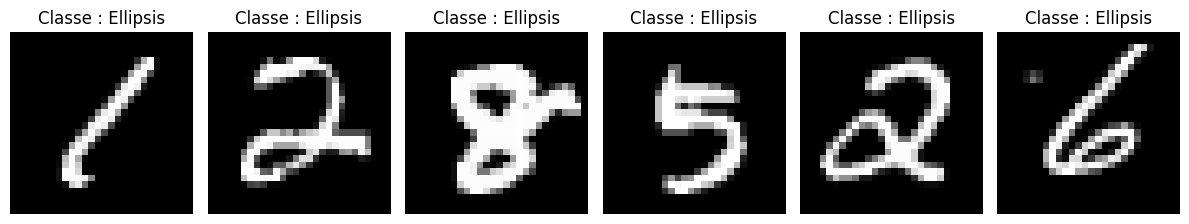

In [9]:
fig, axes = plt.subplots(1, 6, figsize=(12, 3))

for i, ax in enumerate(axes):
    # Annuler la normalisation pour l'affichage
    image = images[i, 0] * 0.3081 + 0.1307

    ax.imshow(image.numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Classe : { ... }")
    ax.axis("off")

plt.tight_layout()
plt.show()

**3. Construire le CNN**

Implémentez cette architecture :

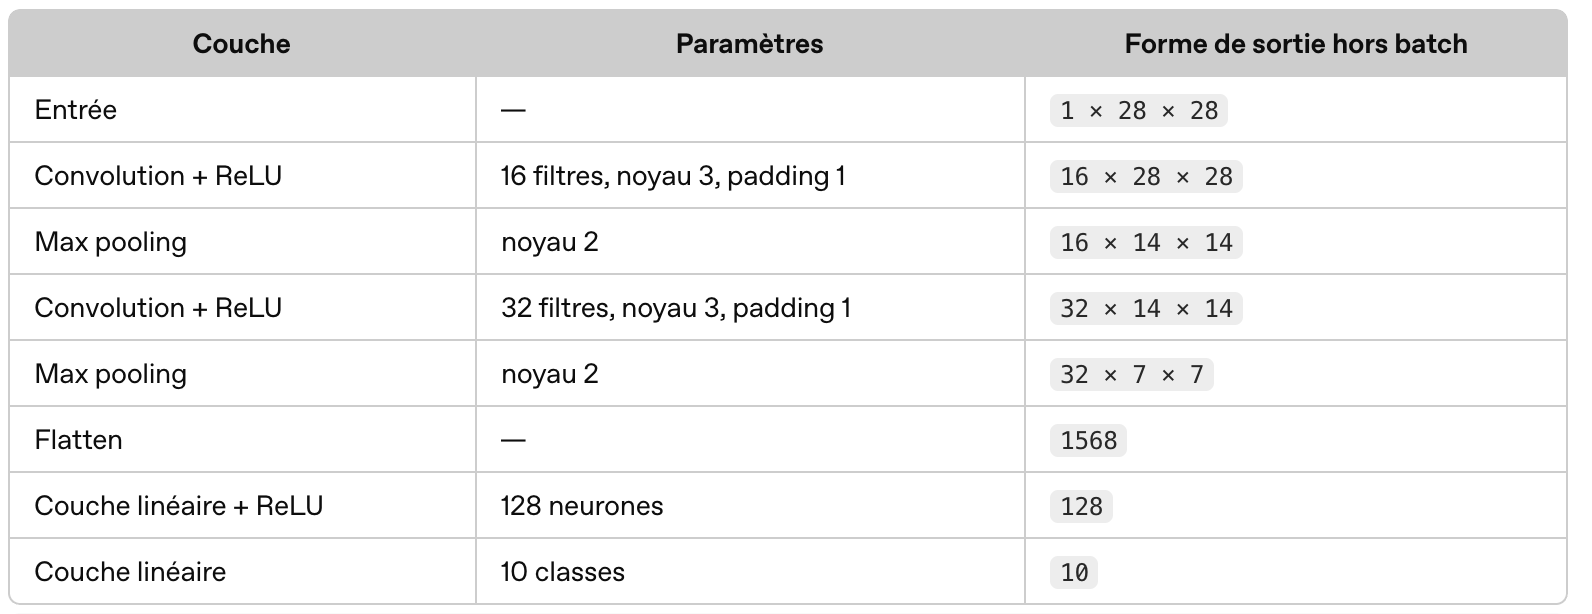

In [ ]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=...,
                out_channels=...,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=...,
                out_channels=...,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(..., 128),
            nn.ReLU(),
            nn.Linear(128, ...)
        )

    def forward(self, x):
        x = ...
        x = ...
        return x


model = MNISTClassifier().to(device)

# Vérifier la forme de sortie
with torch.no_grad():
    output = model(images.to(device))

assert output.shape == (images.size(0), 10)
print("Sortie :", output.shape)

**Question :** pourquoi la première couche linéaire reçoit-elle 32 × 7 × 7 valeurs ?

Attention : n’ajoutez pas de Softmax au modèle. CrossEntropyLoss attend les scores bruts, appelés logits.

**4. Entraîner le réseau**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 3
loss_history = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 1. Réinitialiser les gradients
        ...

        # 2. Calculer les scores
        logits = ...

        # 3. Calculer la perte
        loss = ...

        # 4. Calculer les gradients
        ...

        # 5. Mettre à jour les paramètres
        ...

        total_loss += loss.item() * images.size(0)

    average_loss = total_loss / len(train_dataset)
    loss_history.append(average_loss)

    print(
        f"Époque {epoch + 1}/{epochs} "
        f"| Perte : {average_loss:.4f}"
    )

**5. Évaluer sur le jeu de test**

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        # Classe ayant le score le plus élevé
        predictions = ...

        # Compter les bonnes prédictions
        correct += ...
        total += labels.size(0)

accuracy = correct / total
print(f"Accuracy sur le test : {accuracy:.2%}")

**Indices :**

- argmax(dim=1) sélectionne une classe pour chaque image ;
(predictions == labels).sum().item() compte les prédictions correctes.

- Résultat attendu : une accuracy généralement supérieure à 97 % après quelques époques, sans garantie exacte.

**Autres questions :**

- Affichez 10 images mal classées, avec leur vraie classe et la prédiction.
- Ajoutez une couche Dropout avant la dernière couche linéaire.
- Sauvegardez les paramètres avec torch.save(model.state_dict(), "mnist_cnn.pth").